# Predicting Major League Baseball Game Over/Under Outcomes
The growth of sports analytics and the accessibility of detailed baseball data have made it
increasingly feasible to apply machine learning techniques to real-world betting markets. In
Major League Baseball (MLB), one of the most common bet market is the over/under line,
where bettors predict whether the total number of runs scored in a game will be higher (over) or
lower (under) than the sportsbook’s line. These lines are created using highly sophisticated
models and extensive data, making them an extremely strong benchmark for predictive
performance. 


The goal of this project is to build a model capable of predicting the total runs scored in MLB
games and to evaluate its performance relative to the sportsbooks over/under line, hopefully
outperforming the Vegas models. Since Las Vegas has historically been the center of legal American sports betting, sportsbook models are often referred to as Vegas models.


In this context, ‘outperforming’ the Vegas models means if
the predictions from the model generated were used to place bets, it would generate a positive
return on investment over time. While this serves as the primary objective, it is important to
acknowledge that consistently beating the sportsbook models is highly unlikely due to their
models being some of the most advanced and well-calibrated predictive models in the sports
world. As a result, the Vegas lines are treated as a benchmark for determining model quality and
predictive performance. If this project’s models were able to outperform them, it would indicate
a significant and unexpected result.


To address this problem, a dataset is constructed by combining publicly available MLB game,
player, and team data from the MLB StatsAPI with historical betting lines sourced from a
structured odds dataset. The data is limited to the 2021-2025 seasons due to a paywall. Each
observation represents a single game and includes features such as team hitting performance
metrics, starting pitcher metrics, and rolling metrics calculated using previous games to avoid
data leakage. This ensures that the model reflects a realistic prediction setting.
Using this constructed dataset, multiple modeling techniques will be explored, such as XG
Boosting and random forest, due to their ability to capture complex data relationships and reduce
overfitting. The overall modeling pipeline includes data collection, feature engineering,
preprocessing, and model evaluation. This project ultimately aims to evaluate whether publicly
available data and machine learning techniques can approximate or approach the performance of
sportsbook models. 

In [2]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

import xgboost as xgb

# local import
from ROI import prepare_bets, plot_returns, summarize_results

In [12]:
# load data
df = pd.read_csv('../Data/model.csv')

# target variable
y = df['total_line']

# features
# dropped unneeded columns
X = df.drop([
    'game_date', 'home_team', 'away_team',
    'home_pitcher_name', 'away_pitcher_name',
    'venue', 'over_odds', 'under_odds',
    'total_line', 'total_runs',
    'home_runs', 'away_runs'], axis=1)

Since the data is time-based, instead of randomly splitting into test/train sets, I will train the model on seasons 2021-2024 and use the 2025 season as the test data.

In [14]:
X_train = X[X["season"] < 2025].drop('season', axis=1)
X_test = X[X["season"] == 2025].drop('season', axis=1)

y_train = y[df["season"] < 2025]
y_test = y[df["season"] == 2025]


# time series cross-validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

### Baseline Model: Simple Linear Regression

Before implementing more complex machine learning models such as XGBoost and Random Forest, a simple linear regression model is used as a baseline. This provides a benchmark to evaluate whether more advanced models meaningfully improve predictive performance. 

To keep this baseline model as simple as possible, no feature selection will be used.

The goal of this model is to predict the Vegas over/under line (`total_line`) using the engineered features from the dataset. While linear regression is limited in capturing complex nonlinear relationships, it offers interpretability and serves as a useful point of comparison.

Model performance will be evaluated using standard regression metrics such as Mean Squared Error (MSE) and Mean Absolute Error (MAE), as well as betting-based metrics (ROI) for consistency with the overall project objective.

In [17]:
# pipeline
pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# fit model
pipeline_lr.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [25]:
# predictions
y_lr_pred = pipeline_lr.predict(X_test)


# regression metrics
mae = mean_absolute_error(y_test, y_lr_pred)
mse = mean_squared_error(y_test, y_lr_pred)

print("Linear Regression Performance:")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")

Linear Regression Performance:
MAE: 0.6570
MSE: 0.7939


{'num_bets': 878,
 'wins': 411,
 'losses': 438,
 'pushes': 29,
 'total_profit_units': -80.30868571092783,
 'total_risked_units': 849.0,
 'roi': -0.09459209153230605,
 'win_rate': 0.4840989399293286}

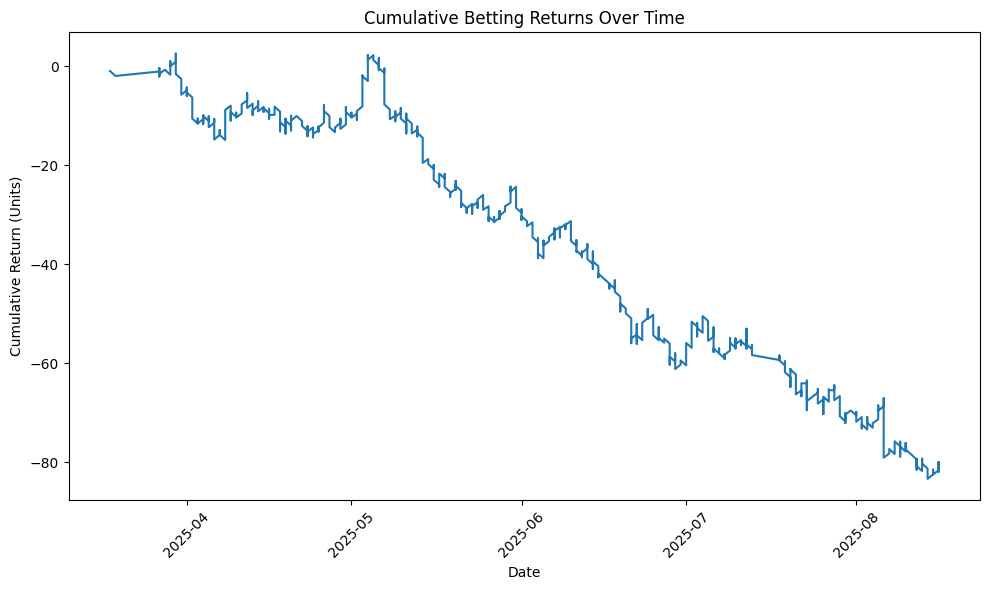

In [22]:
# betting evaluation
df_eval = pd.DataFrame({
    "game_date": df.loc[X_test.index, "game_date"],
    "pred_total": y_lr_pred,
    "vegas_line": df.loc[X_test.index, "total_line"],
    "actual_total": df.loc[X_test.index, "total_runs"],
    "over_odds": df.loc[X_test.index, "over_odds"],
    "under_odds": df.loc[X_test.index, "under_odds"]
}).reset_index(drop=True)

bets = prepare_bets(df_eval, threshold=0.5, stake=1.0)
plot_returns(bets)

summary = summarize_results(bets)
summary

#### Results and Interpretation

The simple linear regression model achieved a Mean Absolute Error (MAE) of 0.6570 and a Mean Squared Error (MSE) of 0.7939 on the 2025 test set. On average, predictions differ from the Vegas line by less than one run, indicating that even a basic model captures some structure in the data.

However, this predictive performance does not translate into betting success. The model placed 878 bets, resulting in 411 wins, 438 losses, and 29 pushes, for a total loss of 80.31 units and an ROI of -9.46%. The win rate of 48.41% falls below the level required to overcome sportsbook odds.The cumulative returns show a clear downward trend over time, with no sustained periods of profitability. This suggests the model does not provide a meaningful edge against the market.


These results highlight the gap between prediction accuracy and betting profitability. While the model approximates the Vegas line reasonably well, it fails to outperform it. This is expected given the efficiency of sportsbook models.

Overall, linear regression provides a useful baseline, but more flexible models are needed to capture nonlinear relationships and improve performance.

### Model: Random Forest

To build on the linear regression baseline, a Random Forest model is implemented to better capture nonlinear relationships and interactions between features. Given the complexity of factors influencing total runs in MLB games, a more flexible model is expected to improve predictive performance.

A pipeline is used for consistency across models. Although Random Forest does not require feature scaling, the scaler is included to maintain a uniform structure throughout the notebook. Model hyperparameters are tuned using RandomizedSearchCV with TimeSeriesSplit, ensuring that model selection respects the time-ordered nature of the data while improving performance.


The same time-based split is used, training on seasons 2021–2024 and evaluating on the 2025 season. Performance is assessed using both regression metrics (MAE and RMSE) and betting-based metrics (ROI), allowing for direct comparison with the linear regression baseline.

In [27]:
# pipeline
pipeline_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# parameter grid
grid_rf = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

In [28]:
# random grid search
random_search_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=grid_rf,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    refit=True
)

# fit
random_search_rf.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,n_iter,25
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [32]:
# best model
best_model_rf = random_search_rf.best_estimator_

# predictions
y_rf_pred = best_model_rf.predict(X_test)

# metrics
mae_rf = mean_absolute_error(y_test, y_rf_pred)
mse_rf = mean_squared_error(y_test, y_rf_pred)

print("Best Parameters:", random_search_rf.best_params_)
print("Random Forest Performance:")
print(f"MAE: {mae_rf:.4f}")
print(f"MSE: {mse_rf:.4f}")

Best Parameters: {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': 20}
Random Forest Performance:
MAE: 0.6329
MSE: 0.7403


{'num_bets': 864,
 'wins': 411,
 'losses': 424,
 'pushes': 29,
 'total_profit_units': -65.43831229501626,
 'total_risked_units': 835.0,
 'roi': -0.0783692362814566,
 'win_rate': 0.49221556886227547}

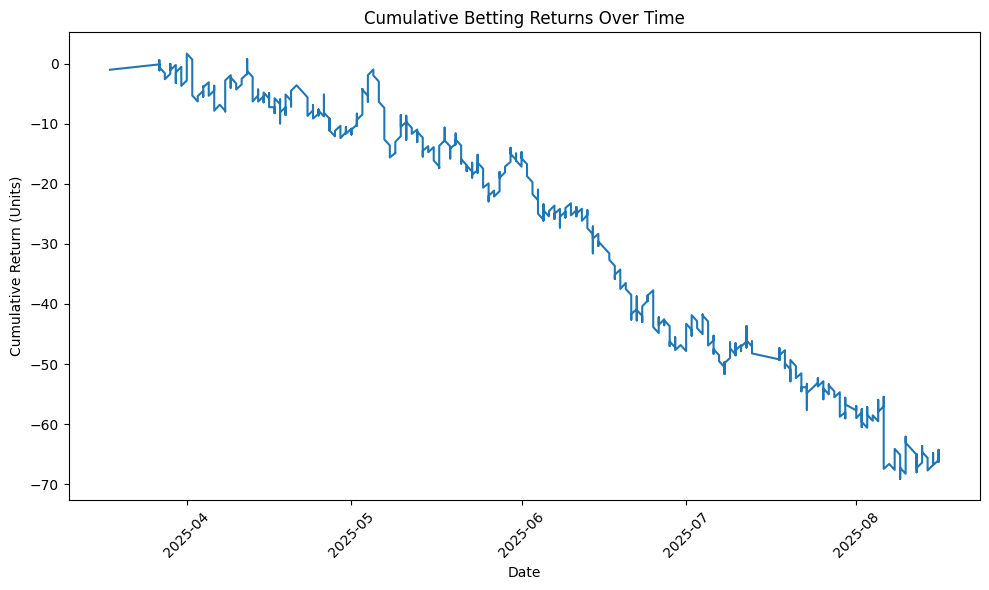

In [34]:
# betting metrics
df_eval_rf = pd.DataFrame({
    "game_date": df.loc[X_test.index, "game_date"],
    "pred_total": y_rf_pred,
    "vegas_line": df.loc[X_test.index, "total_line"],
    "actual_total": df.loc[X_test.index, "total_runs"],
    "over_odds": df.loc[X_test.index, "over_odds"],
    "under_odds": df.loc[X_test.index, "under_odds"]
}).reset_index(drop=True)

bets_rf = prepare_bets(df_eval_rf, threshold=0.5, stake=1.0)
plot_returns(bets_rf)

summary_rf = summarize_results(bets_rf)
summary_rf

#### Results and Interpretation

The Random Forest model achieved a Mean Absolute Error (MAE) of 0.6329 and a Mean Squared Error (MSE) of 0.7403 on the 2025 test set. This represents a modest improvement over the linear regression baseline, suggesting that the model is able to capture some nonlinear structure in the data.

Despite this improvement in predictive accuracy, betting performance remains negative. The model placed 864 bets, resulting in 411 wins, 424 losses, and 29 pushes, for a total loss of 65.44 units and an ROI of -7.84%. The win rate of 49.22% is closer to breakeven than the linear model, but still insufficient to overcome sportsbook margins.

The cumulative returns show a consistent downward trend, although the decline is less steep than in the linear regression case. This indicates that while the Random Forest model provides better predictions, it still does not identify a profitable betting edge.

Overall, the Random Forest model improves upon the linear baseline in both prediction error and ROI, but the gains are not enough to outperform the market. This reinforces the difficulty of beating sportsbook lines and motivates the use of more advanced models such as XGBoost.

### Model: XGBoost without Feature Selection

To further improve predictive performance, an XGBoost model is implemented. XGBoost is a gradient boosting algorithm that builds an ensemble of decision trees sequentially, allowing it to capture complex nonlinear relationships and interactions between features.

Unlike the previous models, XGBoost includes built-in regularization and feature weighting, which reduces the need for explicit feature selection. For this reason, the initial model is trained using the full feature set.

A pipeline is used for consistency with previous models. Hyperparameters are tuned using RandomizedSearchCV with TimeSeriesSplit to ensure that model selection respects the time-ordered nature of the data.

The same time-based split is used, training on seasons 2021–2024 and evaluating on the 2025 season. Performance is assessed using both regression metrics (MAE and RMSE) and betting-based metrics (ROI), allowing for direct comparison with the baseline models.

In [35]:
# pipeline
pipeline_xgb = Pipeline([
    ("scaler", StandardScaler()),
    ("model", xgb.XGBRegressor(random_state=42))
])

# parameter grid
grid_xgb = {
    "model__n_estimators": [300, 500, 700, 900],
    "model__learning_rate": [0.01, 0.03, 0.05],
    
     # Make simple trees to reduce overfitting hopefully
    "model__max_depth": [2, 3, 4, 5],
    "model__min_child_weight": [5, 7, 10],
    "model__gamma": [0.2, 0.5, 1],
    
     # sampling randomness to try and prevent overfitting
    "model__subsample": [0.7, 0.8, 0.9, 1],
    "model__colsample_bytree": [0.6, 0.7, 0.8],
    
    "model__reg_alpha": [0.1, 0.5, 1, 2],
    "model__reg_lambda": [0.5, 1, 2, 3]
}

# source for param grid help: https://www.kaggle.com/code/prashant111/a-guide-on-xgboost-hyperparameters-tuning

In [36]:
# randomized search
random_search_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb,
    param_distributions=grid_xgb,
    n_iter=100,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    refit=True
)

# fit
random_search_xgb.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.6, 0.7, ...], 'model__gamma': [0.2, 0.5, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [2, 3, ...], ...}"
,n_iter,100
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [37]:
# best model
best_model_xgb = random_search_xgb.best_estimator_

# predictions
y_xgb_pred = best_model_xgb.predict(X_test)

# metrics
mae_xgb = mean_absolute_error(y_test, y_xgb_pred)
mse_xgb = mean_squared_error(y_test, y_xgb_pred)

print("Best Parameters:", random_search_xgb.best_params_)
print("XGBoost Performance:")
print(f"MAE: {mae_xgb:.4f}")
print(f"MSE: {mse_xgb:.4f}")

Best Parameters: {'model__subsample': 0.7, 'model__reg_lambda': 3, 'model__reg_alpha': 0.5, 'model__n_estimators': 700, 'model__min_child_weight': 7, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__gamma': 0.5, 'model__colsample_bytree': 0.7}
XGBoost Performance:
MAE: 0.6162
MSE: 0.7142


{'num_bets': 847,
 'wins': 407,
 'losses': 416,
 'pushes': 24,
 'total_profit_units': -60.47423409428104,
 'total_risked_units': 823.0,
 'roi': -0.07348023583752253,
 'win_rate': 0.4945321992709599}

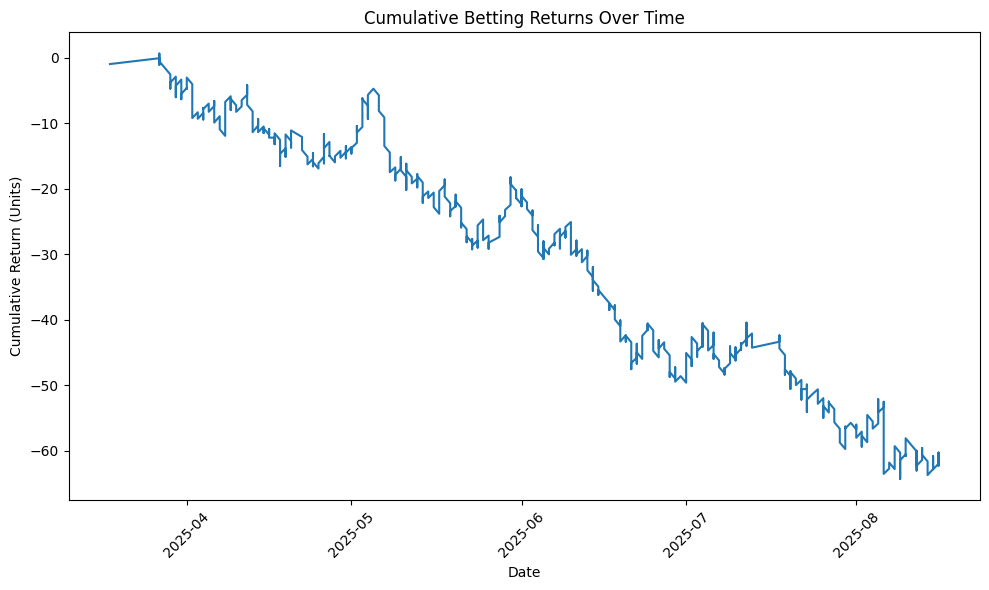

In [38]:
# betting metrics
df_eval_xgb = pd.DataFrame({
    "game_date": df.loc[X_test.index, "game_date"],
    "pred_total": y_xgb_pred,
    "vegas_line": df.loc[X_test.index, "total_line"],
    "actual_total": df.loc[X_test.index, "total_runs"],
    "over_odds": df.loc[X_test.index, "over_odds"],
    "under_odds": df.loc[X_test.index, "under_odds"]
}).reset_index(drop=True)

bets_xgb = prepare_bets(df_eval_xgb, threshold=0.5, stake=1.0)
plot_returns(bets_xgb)

summary_xgb = summarize_results(bets_xgb)
summary_xgb

#### Feature Selection

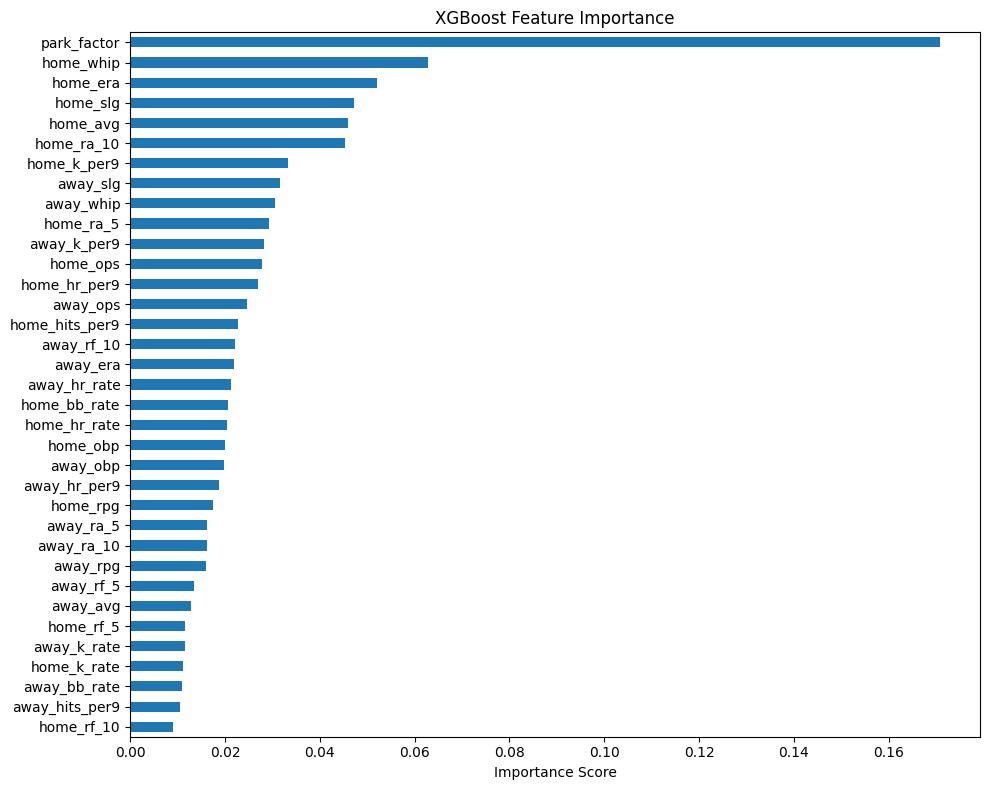

In [50]:
model = best_model_xgb.named_steps["model"]

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importance.plot(kind="barh")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

#### Results and Interpretation

The XGBoost model achieved a Mean Absolute Error (MAE) of 0.6162 and a Mean Squared Error (MSE) of 0.7142 on the 2025 test set. This represents a clear improvement over both the linear regression and Random Forest models, indicating that XGBoost is better able to capture the complex relationships present in the data.

From a betting perspective, the model placed 847 bets, resulting in 407 wins, 416 losses, and 24 pushes. This corresponds to a total loss of 60.47 units and an ROI of -7.35%, with a win rate of 49.45%. While still negative, this is the best performance observed so far across all models.
The cumulative returns plot shows a downward trend, but with a slower rate of decline compared to previous models. This suggests that while XGBoost improves prediction accuracy and reduces losses, it still does not generate a consistent betting edge against the market.

Feature importance results show that park_factor is by far the most influential variable, followed by a mix of pitching and offensive metrics. This aligns with expectations, as ballpark environment and starting pitcher quality are key drivers of run scoring in MLB games.

Overall, XGBoost provides the strongest predictive performance and the least negative ROI among the models tested. However, the results reinforce the difficulty of outperforming sportsbook lines, even with advanced machine learning techniques.

### Model: XGBoost With Feature Selection

To evaluate whether reducing the feature space improves model performance, a second XGBoost model is trained with an added feature selection step. Feature selection is performed using a tree-based model within the pipeline, allowing less important variables to be removed before fitting XGBoost.

This approach tests whether eliminating noise or redundant features can improve generalization and potentially enhance betting performance. The same time-based split and hyperparameter tuning procedure are used, allowing for a direct comparison with the XGBoost model trained on the full feature set.

In [55]:
# pipeline with feature selection
pipeline_xgb_fs = Pipeline([
    ("scaler", StandardScaler()),
    ("feature_selection", SelectFromModel(RandomForestRegressor(random_state=42))),
    ("model", xgb.XGBRegressor(random_state=42))
])

# same grid (include threshold)
grid_xgb_fs = {
    "model__n_estimators": [300, 500, 700, 900],
    "model__learning_rate": [0.01, 0.03, 0.05],
    
     # Make simple trees to reduce overfitting hopefully
    "model__max_depth": [2, 3, 4, 5],
    "model__min_child_weight": [5, 7, 10],
    "model__gamma": [0.2, 0.5, 1],
    
     # sampling randomness to try and prevent overfitting
    "model__subsample": [0.7, 0.8, 0.9, 1],
    "model__colsample_bytree": [0.6, 0.7, 0.8],
    
    "model__reg_alpha": [0.1, 0.5, 1, 2],
    "model__reg_lambda": [0.5, 1, 2, 3],
    
    # Feature selection tuning
    "feature_selection__threshold": ["median", "mean", 0.01, 0.02]
}


In [52]:
# randomized search
random_search_xgb_fs = RandomizedSearchCV(
    estimator=pipeline_xgb_fs,
    param_distributions=grid_xgb_fs,
    n_iter=100,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    refit=True
)

# fit
random_search_xgb_fs.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'feature_selection__threshold': ['median', 'mean', ...], 'model__colsample_bytree': [0.6, 0.7, ...], 'model__gamma': [0.2, 0.5, ...], 'model__learning_rate': [0.01, 0.03, ...], ...}"
,n_iter,100
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [53]:
# best model
best_model_xgb_fs = random_search_xgb_fs.best_estimator_

# predictions
y_xgb_fs_pred = best_model_xgb_fs.predict(X_test)

# metrics
mae_xgb_fs = mean_absolute_error(y_test, y_xgb_fs_pred)
mse_xgb_fs = mean_squared_error(y_test, y_xgb_fs_pred)

print("Best Parameters:", random_search_xgb_fs.best_params_)
print("XGBoost Performance:")
print(f"MAE: {mae_xgb_fs:.4f}")
print(f"MSE: {mse_xgb_fs:.4f}")

Best Parameters: {'model__subsample': 0.7, 'model__reg_lambda': 2, 'model__reg_alpha': 0.5, 'model__n_estimators': 900, 'model__min_child_weight': 7, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__gamma': 0.2, 'model__colsample_bytree': 0.7, 'feature_selection__threshold': 0.01}
XGBoost Performance:
MAE: 0.6152
MSE: 0.7130


{'num_bets': 842,
 'wins': 404,
 'losses': 413,
 'pushes': 25,
 'total_profit_units': -60.35199927142041,
 'total_risked_units': 817.0,
 'roi': -0.07387025614616942,
 'win_rate': 0.4944920440636475}

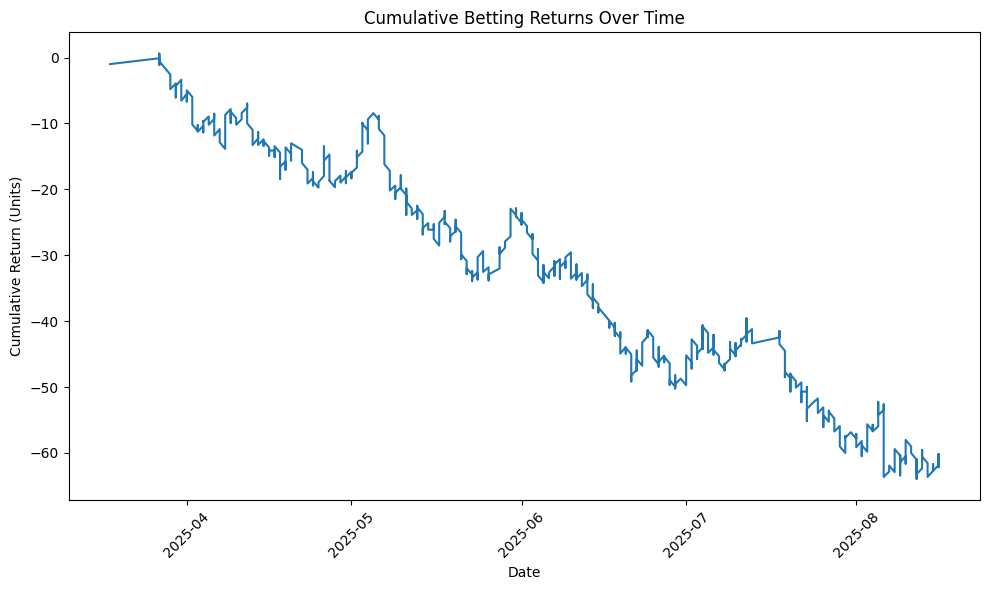

In [57]:
# betting metrics
df_eval_xgb = pd.DataFrame({
    "game_date": df.loc[X_test.index, "game_date"],
    "pred_total": y_xgb_fs_pred,
    "vegas_line": df.loc[X_test.index, "total_line"],
    "actual_total": df.loc[X_test.index, "total_runs"],
    "over_odds": df.loc[X_test.index, "over_odds"],
    "under_odds": df.loc[X_test.index, "under_odds"]
}).reset_index(drop=True)

bets_xgb = prepare_bets(df_eval_xgb, threshold=0.5, stake=1.0)
plot_returns(bets_xgb)

summary_xgb = summarize_results(bets_xgb)
summary_xgb

#### Feature Selection

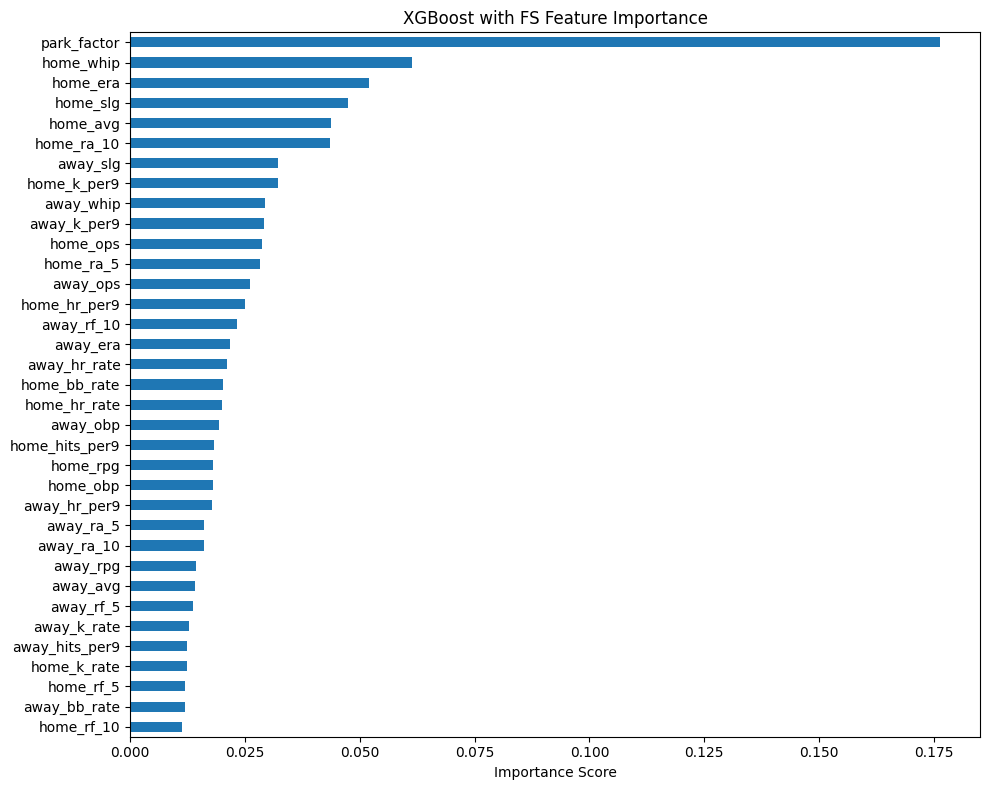

In [56]:
model = best_model_xgb_fs.named_steps["model"]

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importance.plot(kind="barh")
plt.title("XGBoost with FS Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

#### Results and Interpretation

The XGBoost model with feature selection achieved a Mean Absolute Error (MAE) of 0.6152 and a Mean Squared Error (MSE) of 0.7130 on the 2025 test set. This represents a very slight improvement over the XGBoost model trained on the full feature set, indicating that removing less important variables may help reduce noise and improve generalization.

From a betting perspective, the model placed 842 bets, resulting in 404 wins, 413 losses, and 25 pushes. This corresponds to a total loss of 60.35 units and an ROI of -7.39%, with a win rate of 49.45%. These results are nearly identical to the no-feature-selection model, suggesting that feature selection does not meaningfully change betting performance.

The cumulative returns show a similar downward trend to the previous XGBoost model, reinforcing the conclusion that while predictive accuracy has improved, a consistent edge against the sportsbook has not been achieved.

Feature importance results remain largely unchanged, with park_factor continuing to dominate, followed by a mix of pitching and offensive metrics. This consistency suggests that the most important drivers of the model are stable even when less relevant features are removed.

It is also important to note that this model required significantly more computational time to train due to the added feature selection step within the hyperparameter tuning process. Given the minimal performance gains, this additional complexity does not appear to be justified.

Overall, feature selection provides only marginal improvements in prediction error and does not materially impact ROI. This indicates that XGBoost is already effective at handling feature importance internally, and that additional feature selection offers limited benefit in this setting.

## Threshold Optimization for Betting Strategy

The previous models used a fixed threshold (0.5) to determine when to place bets, based on the difference between the predicted total and the Vegas line. However, this threshold directly controls both the number of bets placed and the level of confidence required to act on a prediction.

To better evaluate the practical performance of the model, the threshold is optimized using the best-performing model (XGBoost without feature selection). A range of threshold values is tested, and the resulting return on investment (ROI) is calculated for each.

This analysis allows us to determine whether a more selective betting strategy, based on higher-confidence predictions, can improve profitability and potentially generate a positive edge against the market.

In [58]:
# test different thresholds
thresholds = np.linspace(0.1, 2.0, 40)

results = []

for t in thresholds:
    bets = prepare_bets(df_eval_xgb, threshold=t, stake=1.0)
    summary = summarize_results(bets)
    
    results.append({
        "threshold": t,
        "roi": summary["roi"],
        "num_bets": summary["num_bets"],
        "win_rate": summary["win_rate"]
    })

results_df = pd.DataFrame(results)

# best threshold
best_row = results_df.loc[results_df["roi"].idxmax()]
best_row

threshold     1.707692
roi          -0.005069
num_bets     63.000000
win_rate      0.539683
Name: 33, dtype: float64

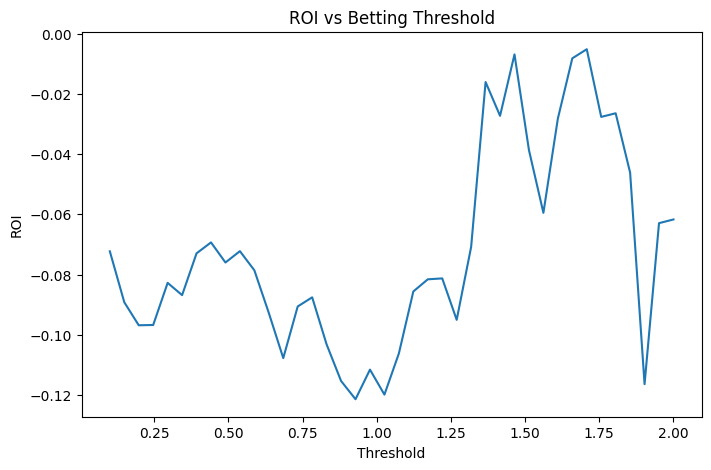

In [63]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["threshold"], results_df["roi"])
plt.xlabel("Threshold")
plt.ylabel("ROI")
plt.title("ROI vs Betting Threshold")
plt.show()

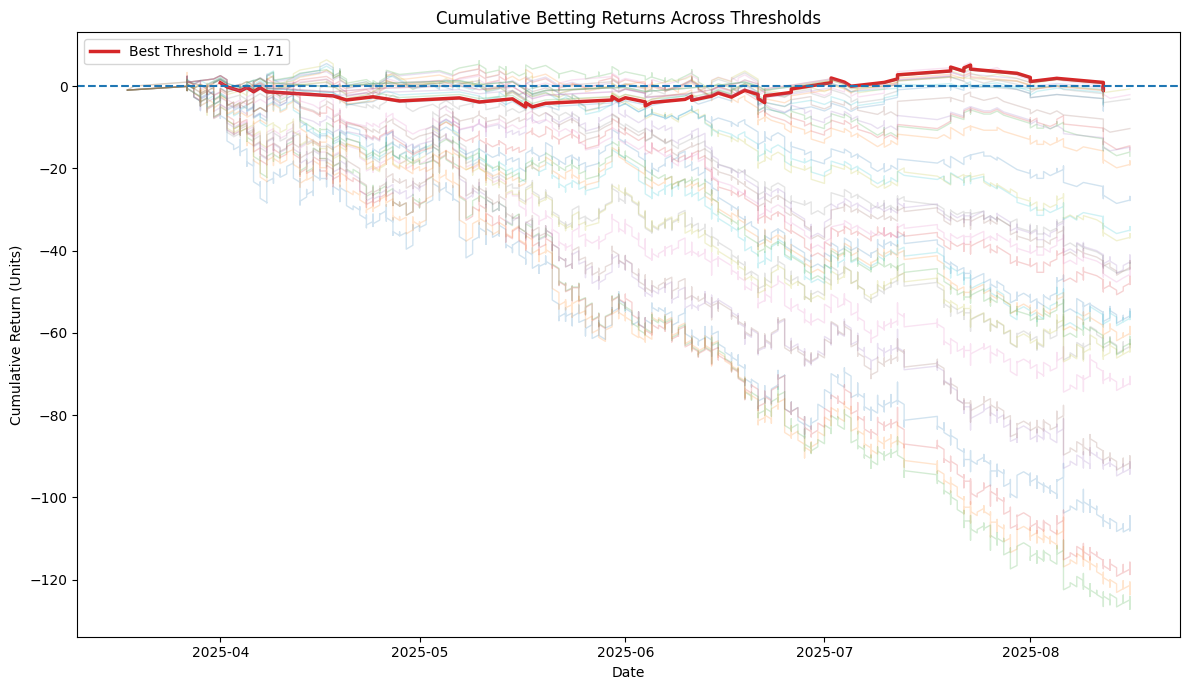

In [60]:
plt.figure(figsize=(12, 7))

best_threshold = best_row["threshold"]

for t in thresholds:
    bets_t = prepare_bets(df_eval_xgb, threshold=t, stake=1.0)
    
    if np.isclose(t, best_threshold):
        plt.plot(
            bets_t["game_date"],
            bets_t["cumulative_profit"],
            linewidth=2.5,
            label=f"Best Threshold = {t:.2f}"
        )
    else:
        plt.plot(
            bets_t["game_date"],
            bets_t["cumulative_profit"],
            alpha=0.2,
            linewidth=1
        )

plt.axhline(0, linestyle="--")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (Units)")
plt.title("Cumulative Betting Returns Across Thresholds")
plt.legend()
plt.tight_layout()
plt.show()

### Results and Interpretation

Optimizing the betting threshold using the XGBoost model results in a best threshold of approximately 1.71. At this level, the model places only 63 bets, significantly fewer than previous strategies, and achieves an ROI of -0.51% with a win rate of 53.97%.

Notably, even with a win rate above 53%, the model still produces a slightly negative ROI. This highlights the impact of sportsbook odds, where the required breakeven win rate is typically higher than 50%, meaning that a majority of correct predictions does not necessarily translate into profitability.

This represents a substantial improvement over the fixed-threshold approaches used earlier, reducing losses from approximately -7% ROI to near breakeven. The ROI vs. threshold plot shows a clear pattern: as the threshold increases, the model becomes more selective, and performance improves. However, no threshold produces a consistently positive ROI.

The cumulative returns across thresholds further reinforce this result. While most thresholds show steady losses over time, the optimal threshold produces a relatively flat trajectory, with periods of slight gains but no sustained upward trend. This indicates that focusing only on high-confidence predictions reduces losses but does not create a reliable betting edge.

A key tradeoff emerges from this analysis. Higher thresholds improve win rate and reduce losses, but they also drastically reduce the number of betting opportunities. In this case, the model achieves its best performance by placing very few bets, limiting its practical usefulness.

Overall, threshold optimization demonstrates that even under ideal conditions, using the best-performing model and selecting only the most confident predictions, the model is unable to consistently outperform sportsbook lines. This reinforces the conclusion that while machine learning models can approximate betting markets, generating a profitable edge remains extremely difficult.

## Ethical Considerations

While this project focuses on predictive modeling in sports betting, it is important to consider the ethical implications of applying machine learning in this context.

First, sports betting involves financial risk, and models such as those developed in this project may create a false sense of confidence in predictive accuracy. Even when models show improved performance metrics, they may still lead to financial losses, as demonstrated by the consistently negative ROI results. This highlights the importance of responsible use and clear communication of model limitations.

Second, the use of publicly available data raises fewer privacy concerns compared to other domains, but the broader application of machine learning in betting markets may contribute to increased gambling activity. This can have negative social consequences, particularly for individuals vulnerable to problem gambling.

Finally, this project reinforces the idea that markets such as sports betting are highly efficient, and that attempts to exploit them using standard machine learning techniques are unlikely to succeed. This serves as an important reminder that predictive models should be used carefully and ethically, especially in high-risk decision-making environments.

Overall, while the modeling approach is technically sound, its real-world application should be considered with caution.

## Final Comparison and Conclusion

Across all models, a clear pattern emerges: improvements in predictive accuracy do not translate into profitable betting performance.

The linear regression model provided a simple baseline, achieving reasonable prediction error but producing a negative ROI of approximately -9.46%. The Random Forest model improved predictive performance and reduced losses, achieving an ROI of -7.84%. XGBoost further improved accuracy, achieving the lowest error metrics and the least negative ROI at approximately -7.35%.

Adding feature selection to XGBoost resulted in only marginal improvements in prediction error, with virtually no change in ROI. This suggests that XGBoost is already effective at handling feature importance internally, and that additional feature selection provides limited benefit in this context.

To further evaluate practical performance, threshold optimization was applied to the best-performing model. By increasing the threshold to approximately 1.71, the model became highly selective, placing only 63 bets and improving ROI to -0.51%. While this represents a substantial reduction in losses, no threshold produced a consistently positive return.

A key insight from this analysis is that even achieving a win rate above 50% is not sufficient for profitability. At the optimal threshold, the model achieved a win rate of 53.97%, yet still produced a negative ROI due to the structure of sportsbook odds. This highlights the difficulty of overcoming the inherent margin built into betting markets.

Although the models do not generate a positive ROI, they still provide scientific value. The consistent improvements in MAE and MSE across models demonstrate that machine learning methods can effectively capture patterns in MLB run scoring and approximate sportsbook lines. From a predictive modeling perspective, the results show that publicly available data contains meaningful signal, even if it is not sufficient to create a profitable betting strategy.

Overall, the results demonstrate that while machine learning models can approximate sportsbook lines and improve predictive accuracy, generating a consistent betting edge is extremely difficult. Even with advanced models, hyperparameter tuning, feature engineering, and strategy optimization, the models were unable to outperform the market.

These findings reinforce the efficiency of sportsbook pricing and suggest that publicly available data and standard machine learning approaches are insufficient to consistently exploit mispricing in MLB over/under markets.